# Analysis for best_model.zip

----------------- Running RMSE Analysis for sac -----------------
----------------- Model Used <stable_baselines3.sac.sac.SAC object at 0x000002EBB88723C0> -----------------
----------------- Running RMSE Analysis for sac_2 -----------------
----------------- Model Used <stable_baselines3.sac.sac.SAC object at 0x000002EBCFE56240> -----------------


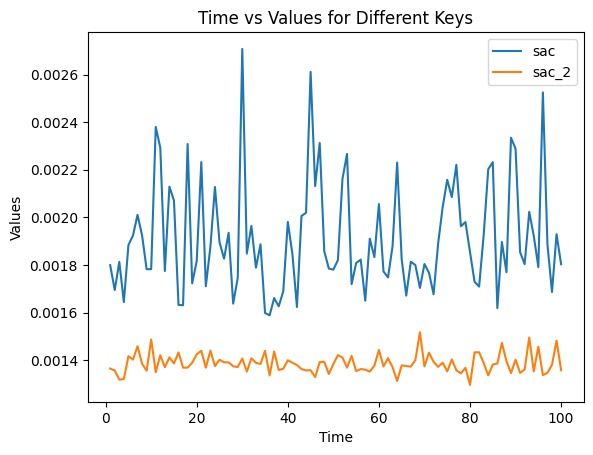

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline
import utils
import os
from stable_baselines3 import PPO,SAC,A2C,TD3, DDPG
import utils

experiments = os.listdir("experiments")
experiment_names = []

figure_data = {}

for experiment_name in experiments:

    experiment_folder = os.path.join("experiments",experiment_name)
    best_model_folder = os.path.join(experiment_folder, "model" )
    best_model_path = os.path.join(best_model_folder, "best_model.zip")

    if 'PPO' in experiment_name:
        loaded_model = PPO.load(best_model_path)
    elif 'sac' in experiment_name:
        loaded_model = SAC.load(best_model_path)
    elif 'a2c' in experiment_name:
        loaded_model = A2C.load(best_model_path)
    elif 'td3' in experiment_name:
        loaded_model = TD3.load(best_model_path)
    elif 'ddpg' in experiment_name:
        loaded_model = DDPG.load(best_model_path)
    
    print(f"----------------- Running RMSE Analysis for {experiment_name} -----------------")
    print(f"----------------- Model Used {loaded_model} -----------------")


    figure_data[experiment_name] = []
    num_experiments = 100

    for experiment in range(1, num_experiments+1):
        # Initial conditions
        X0 = config.X0  # CDW g/L 
        S0 = config.S0 # mol/L
        E0 = config.E0 # U/L 

        # Process conditions
        T = config.INIT_TEMPRATURE #'C 
        T_opt = config.OPTIMUM_TEMPERATURE #'C
        A = config.INIT_AGITATION # RPM

        # model parameters
        Ks = config.KS    # mol/L
        Yxs =  config.YXS  # CDW g/mol
        MuE_opt = config.MUE_OPT    # U/CDW g
        mu_max = config.MU_MAX   # /h
        del_t = config.DEL_T # hours ie. 36 seconds
        t_end = config.T_END
        total_sim_steps = int(t_end/del_t)
        tvec = [del_t + i * del_t for i in range(total_sim_steps)]
        ns = len(tvec)
        kl = config.KL # mol/L
        cell_death_timer = config.CELL_DEATH_TIMER
        cell_death_time = config.CELL_DEATH_TIME

        # Substrate addition calculations
        tank_capacity = config.TANK_CAPACITY # L
        substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
        max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
        substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
        media_transfer_gap =  config.MEDIA_TRANSFER_GAP # Hours this is after 10 steps ie. 6 minutes
        media_transfer_step = int(media_transfer_gap/del_t)
        substrate_concentration = S0
        sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

        # external media tank configurations
        ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
        substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

        # X S E delE delX, muE
        D = np.zeros((ns+1, 6))
        D[0][0] = X0
        D[0][1] = substrate_concentration
        D[0][2] = E0
        for i in range(ns):
            X = D[i][0]
            S = D[i][1]
            E = D[i][2]

            MuX = utils.cell_growth_rate(S)
            # new cells that are generated
            dXdt = utils.cells_produced(X, MuX)

            # SUbstrate consumption
            dSdt = utils.substrate_consumed(dXdt)

            # Find change in cells 
            delX = dXdt * del_t
            # Update cells
            D[i+1][0] = X + delX
            
            # Find change in substrate
            delS = dSdt * del_t

            # # Update substrate
            if substrate_in_tank_liters < max_substrate_limit_liters:
                if i%(media_transfer_step) == 0 and i != 0:
                    if loaded_model.observation_space.shape[0] == 2:
                        model_input = np.array([i, E])
                    elif loaded_model.observation_space.shape[0] == 3:
                        model_input = np.array([i, E, X])
                    action = loaded_model.predict(model_input, deterministic=False)
                    substrate_action = action[0][0]
                    if True:
                        # get substrate concentraion for current timestep
                        substrate_concentration = S
                        sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                        # Add substrate and calculate new concentraion
                        substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                        sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                        substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                        S = substrate_concentration

            # Check if substrate is less than or close to 0
            if S + delS < 0.000001:
                D[i+1][1] = 0
            else:
                D[i+1][1] = S + delS

            # Enzyme determination 
            sub_cell_ratio = (S/X) * 1e6

            weibull = utils.get_weibull_y_value(sub_cell_ratio, peak = config.OPT_SUB_CELL_RATIO*1e6)
            MuE = MuE_opt * weibull

            if dXdt == 0:
                MuE = 0

            # new enzyme from fresh cells
            delE = MuE * X * del_t
            
            # Update enzyme variable
            D[i+1][2] = E + delE

            # terminate if tank capacity is full and cells start dying
            if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
                break
            
        X = D[:,0][0:i]
        S = D[:,1][0:i]
        E = D[:,2][0:i]
        ratios = (S/X)
        rmse = utils.calculate_rmse( ratios, config.OPT_SUB_CELL_RATIO )  
        figure_data[experiment_name].append(rmse)


# Time points
time = list(range(1, 101))  # Time from 1 to 100
data = []
label_names = []
# Create a boxplot for each key
fig, ax = plt.subplots()

for key, values in figure_data.items():
    ax.plot(time, values, label=key)
    data.append(values)
    label_names.append(key)

# Customize the plot
ax.set_xlabel('Time')
ax.set_ylabel('Values')
ax.set_title('Time vs Values for Different Keys')
plt.legend()  # Show a legend for each key
plt.show()

# Box Plot

C:\Users\Reuel Group\AppData\Local\Temp\ipykernel_28604\3313023625.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=label_names)


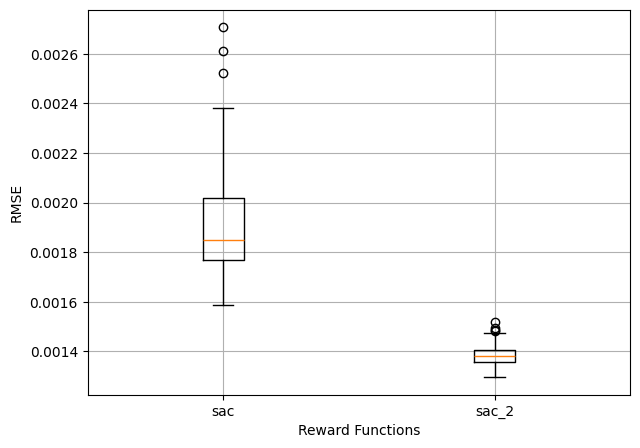

In [2]:
import matplotlib.pyplot as plt

# Combine lists into a single list of lists for the box plot

plt.figure(figsize=(7, 5))
# Create the box plot
plt.boxplot(data, labels=label_names)

# Customize the plot
plt.ylabel('RMSE')
plt.xlabel('Reward Functions')
plt.grid(True)

# Show the plot
plt.show()


# Last saved model RMSE analysis

C:\Users\Reuel Group\AppData\Local\Temp\ipykernel_12984\2054516264.py:175: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()  # Show a legend for each key


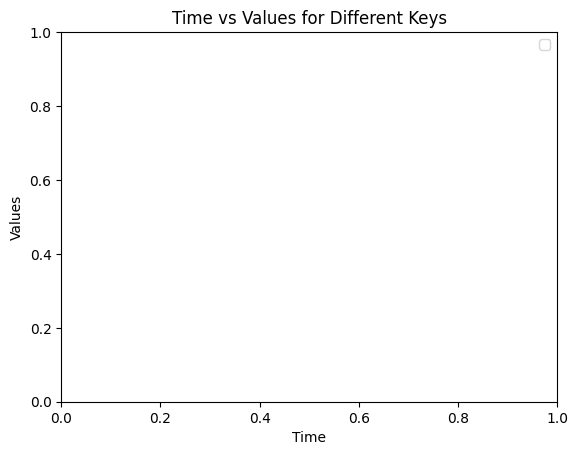

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline
import utils
import os
from stable_baselines3 import PPO,SAC
import utils

figure_data = {}

for experiment_name in experiment_names:
    experiment_folder = os.path.join("experiments",experiment_name)
    best_model_folder = os.path.join(experiment_folder, "model" )
    last_saved_model_name = f"{experiment_name}.zip"
    last_saved_model = os.path.join(best_model_folder, last_saved_model_name)

    if 'ppo' in experiment_name:
        loaded_model = PPO.load(last_saved_model)
    elif 'sac' in experiment_name:
        loaded_model = SAC.load(last_saved_model)
    elif 'a2c' in experiment_name:
        loaded_model = A2C.load(last_saved_model)
    elif 'td3' in experiment_name:
        loaded_model = TD3.load(last_saved_model)
    elif 'ddpg' in experiment_name:
        loaded_model = DDPG.load(last_saved_model)
    
    print(f"----------------- Running RMSE Analysis for {experiment_name} -----------------")
    weibull_values = pd.read_csv('pdfcsv.csv')
    xvalues = weibull_values['x']
    y_values = weibull_values['pdf']

    # Create a cubic spline interpolation model
    cs = CubicSpline(xvalues, y_values)

    figure_data[experiment_name] = []
    num_experiments = 100

    for experiment in range(1, num_experiments+1):
        # Initial conditions
        X0 = config.X0  # CDW g/L 
        S0 = config.S0 # mol/L
        E0 = config.E0 # U/L 

        # Process conditions
        T = config.INIT_TEMPRATURE #'C 
        T_opt = config.OPTIMUM_TEMPERATURE #'C
        A = config.INIT_AGITATION # RPM

        # model parameters
        Ks = config.KS    # mol/L
        Yxs =  config.YXS  # CDW g/mol
        MuE_opt = config.MUE_OPT    # U/CDW g
        mu_max = config.MU_MAX   # /h
        del_t = config.DEL_T # hours ie. 36 seconds
        t_end = config.T_END
        total_sim_steps = int(t_end/del_t)
        tvec = [del_t + i * del_t for i in range(total_sim_steps)]
        ns = len(tvec)
        kl = config.KL # mol/L
        cell_death_timer = config.CELL_DEATH_TIMER
        cell_death_time = config.CELL_DEATH_TIME

        # Substrate addition calculations
        tank_capacity = config.TANK_CAPACITY # L
        substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
        max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
        substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
        media_transfer_gap =  config.MEDIA_TRANSFER_GAP # Hours this is after 10 steps ie. 6 minutes
        media_transfer_step = int(media_transfer_gap/del_t)
        substrate_concentration = S0
        sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

        # external media tank configurations
        ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
        substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

        # X S E delE delX, muE
        D = np.zeros((ns+1, 6))
        D[0][0] = X0
        D[0][1] = substrate_concentration
        D[0][2] = E0
        for i in range(ns):
            X = D[i][0]
            S = D[i][1]
            E = D[i][2]

            MuX = utils.cell_growth_rate(S)
            # new cells that are generated
            dXdt = utils.cells_produced(X, MuX)

            # SUbstrate consumption
            dSdt = utils.substrate_consumed(dXdt)

            # Find change in cells 
            delX = dXdt * del_t
            # Update cells
            D[i+1][0] = X + delX
            
            # Find change in substrate
            delS = dSdt * del_t

           # # Update substrate
            if substrate_in_tank_liters < max_substrate_limit_liters:
                if i%(media_transfer_step) == 0 and i != 0:
                    if loaded_model.observation_space.shape[0] == 2:
                        model_input = np.array([i, E])
                    elif loaded_model.observation_space.shape[0] == 3:
                        model_input = np.array([i, E, X])
                    action = loaded_model.predict(model_input, deterministic=False)
                    substrate_action = action[0][0]
                    if True:
                        # get substrate concentraion for current timestep
                        substrate_concentration = S
                        sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                        # Add substrate and calculate new concentraion
                        substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                        sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                        substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                        S = substrate_concentration

            # Check if substrate is less than or close to 0
            if S + delS < 0.000001:
                D[i+1][1] = 0
            else:
                D[i+1][1] = S + delS

            # Enzyme determination 
            sub_cell_ratio = (S/X) * 1e6

            weibull = utils.enzyme_production_rate(sub_cell_ratio, cs)
            MuE = MuE_opt * weibull

            if dXdt == 0:
                MuE = 0

            # new enzyme from fresh cells
            delE = MuE * X * del_t
            
            # Update enzyme variable
            D[i+1][2] = E + delE

            # terminate if tank capacity is full and cells start dying
            if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
                break
            
        X = D[:,0][0:i]
        S = D[:,1][0:i]
        E = D[:,2][0:i]
        ratios = (S/X)
        rmse = utils.calculate_rmse( ratios, config.OPT_SUB_CELL_RATIO )  
        figure_data[experiment_name].append(rmse)


# Time points
time = list(range(1, 101))  # Time from 1 to 100
data = []
label_names = []
# Create a boxplot for each key
fig, ax = plt.subplots()

for key, values in figure_data.items():
    ax.plot(time, values, label=key)
    data.append(values)
    label_names.append(key)

# Customize the plot
ax.set_xlabel('Time')
ax.set_ylabel('Values')
ax.set_title('Time vs Values for Different Keys')
plt.legend()  # Show a legend for each key
plt.show()

# Box plot

C:\Users\Reuel Group\AppData\Local\Temp\ipykernel_12984\2076037137.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=label_names)


ValueError: Dimensions of labels and X must be compatible

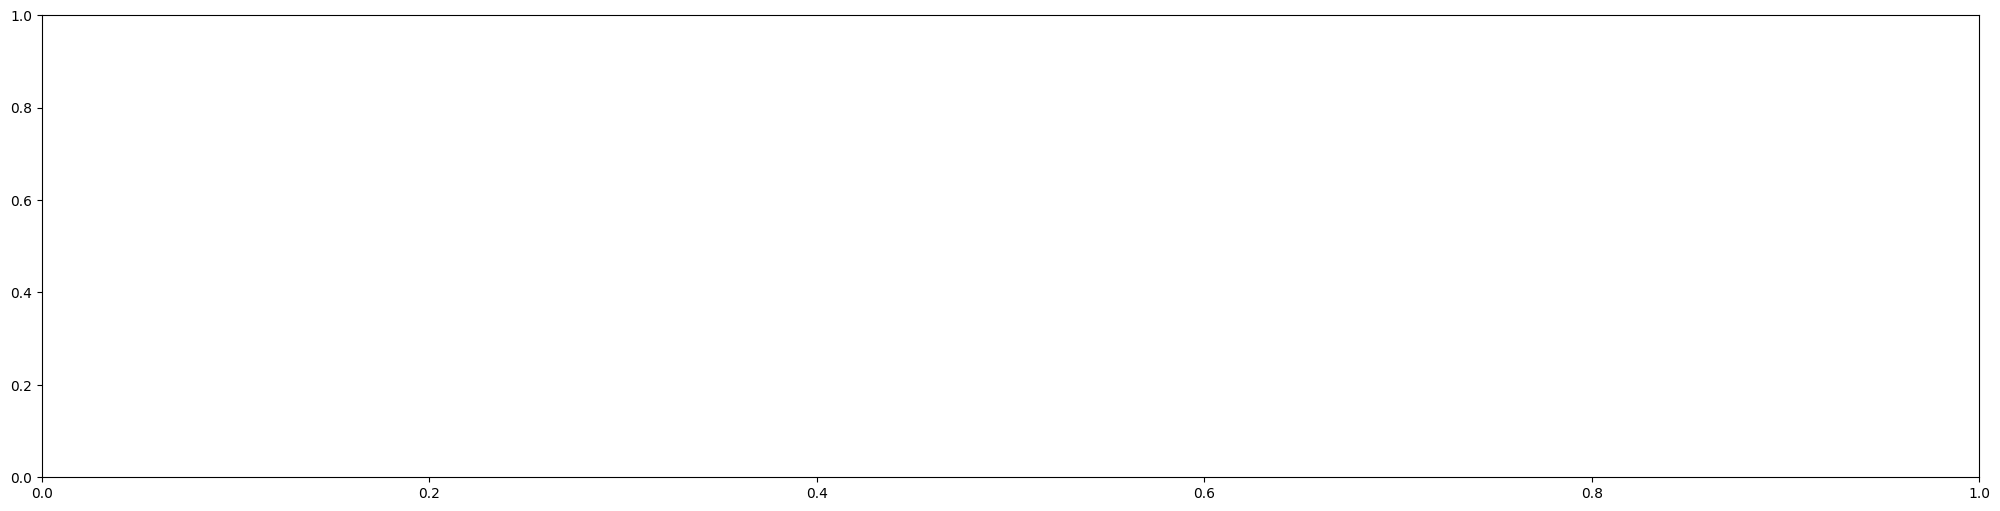

In [5]:
import matplotlib.pyplot as plt

# Combine lists into a single list of lists for the box plot

# Create the box plot
plt.figure(figsize=(25, 6))
plt.boxplot(data, labels=label_names)

# Customize the plot
plt.xlabel('RMSE')
plt.ylabel('Reward Functions')
plt.grid(True)

# Show the plot
plt.show()
